In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [25]:
df = pd.read_csv("C:/data-analysis-portfolio/datasets/Stock Market Dataset.csv")
print(df.head())

   Unnamed: 0        Date  Natural_Gas_Price  Natural_Gas_Vol.  \
0           0  02-02-2024              2.079               NaN   
1           1  01-02-2024              2.050          161340.0   
2           2  31-01-2024              2.100          142860.0   
3           3  30-01-2024              2.077          139750.0   
4           4  29-01-2024              2.490            3590.0   

   Crude_oil_Price  Crude_oil_Vol.  Copper_Price  Copper_Vol. Bitcoin_Price  \
0            72.28             NaN        3.8215          NaN     43,194.70   
1            73.82        577940.0        3.8535          NaN     43,081.40   
2            75.85        344490.0        3.9060          NaN     42,580.50   
3            77.82        347240.0        3.9110          NaN     42,946.20   
4            76.78        331930.0        3.8790          NaN     43,299.80   

   Bitcoin_Vol.  ... Berkshire_Price  Berkshire_Vol. Netflix_Price  \
0       42650.0  ...        5,89,498         10580.0      

In [26]:
print("Shape", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape (1243, 39)

Columns:
Index(['Unnamed: 0', 'Date', 'Natural_Gas_Price', 'Natural_Gas_Vol.',
       'Crude_oil_Price', 'Crude_oil_Vol.', 'Copper_Price', 'Copper_Vol.',
       'Bitcoin_Price', 'Bitcoin_Vol.', 'Platinum_Price', 'Platinum_Vol.',
       'Ethereum_Price', 'Ethereum_Vol.', 'S&P_500_Price', 'Nasdaq_100_Price',
       'Nasdaq_100_Vol.', 'Apple_Price', 'Apple_Vol.', 'Tesla_Price',
       'Tesla_Vol.', 'Microsoft_Price', 'Microsoft_Vol.', 'Silver_Price',
       'Silver_Vol.', 'Google_Price', 'Google_Vol.', 'Nvidia_Price',
       'Nvidia_Vol.', 'Berkshire_Price', 'Berkshire_Vol.', 'Netflix_Price',
       'Netflix_Vol.', 'Amazon_Price', 'Amazon_Vol.', 'Meta_Price',
       'Meta_Vol.', 'Gold_Price', 'Gold_Vol.'],
      dtype='object')

Missing Values:
Unnamed: 0             0
Date                   0
Natural_Gas_Price      0
Natural_Gas_Vol.       4
Crude_oil_Price        0
Crude_oil_Vol.        23
Copper_Price           0
Copper_Vol.           37
Bitcoin_Price          0
Bitco

In [27]:
df.drop("Unnamed: 0", axis=1, inplace=True, errors='ignore')

In [28]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)   

In [29]:

print(df.dtypes)

Date                 datetime64[ns]
Natural_Gas_Price           float64
Natural_Gas_Vol.            float64
Crude_oil_Price             float64
Crude_oil_Vol.              float64
Copper_Price                float64
Copper_Vol.                 float64
Bitcoin_Price                object
Bitcoin_Vol.                float64
Platinum_Price               object
Platinum_Vol.               float64
Ethereum_Price               object
Ethereum_Vol.               float64
S&P_500_Price                object
Nasdaq_100_Price             object
Nasdaq_100_Vol.             float64
Apple_Price                 float64
Apple_Vol.                  float64
Tesla_Price                 float64
Tesla_Vol.                  float64
Microsoft_Price             float64
Microsoft_Vol.              float64
Silver_Price                float64
Silver_Vol.                 float64
Google_Price                float64
Google_Vol.                 float64
Nvidia_Price                float64
Nvidia_Vol.                 

In [30]:
cols = ['Bitcoin_Price','Platinum_Price','Ethereum_Price',
        'S&P_500_Price','Nasdaq_100_Price','Berkshire_Price','Gold_Price']

for col in cols:
    df[col] = df[col].astype(str).str.replace(",", "", regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [31]:
print(df.dtypes)

Date                 datetime64[ns]
Natural_Gas_Price           float64
Natural_Gas_Vol.            float64
Crude_oil_Price             float64
Crude_oil_Vol.              float64
Copper_Price                float64
Copper_Vol.                 float64
Bitcoin_Price               float64
Bitcoin_Vol.                float64
Platinum_Price              float64
Platinum_Vol.               float64
Ethereum_Price              float64
Ethereum_Vol.               float64
S&P_500_Price               float64
Nasdaq_100_Price            float64
Nasdaq_100_Vol.             float64
Apple_Price                 float64
Apple_Vol.                  float64
Tesla_Price                 float64
Tesla_Vol.                  float64
Microsoft_Price             float64
Microsoft_Vol.              float64
Silver_Price                float64
Silver_Vol.                 float64
Google_Price                float64
Google_Vol.                 float64
Nvidia_Price                float64
Nvidia_Vol.                 

In [22]:
df.describe()

,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Vol.,Platinum_Vol.,Ethereum_Vol.,...,Nvidia_Price,Nvidia_Vol.,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Vol.
count,1243,1243.000000,1239.000000,1243.000000,1.220000e+03,1243.000000,1206.000000,1.243000e+03,636.000000,1.243000e+03,...,1243.000000,1.243000e+03,1243.000000,1243.000000,1.243000e+03,1243.000000,1.243000e+03,1243.000000,1.243000e+03,1241.000000
mean,2021-08-02 10:03:34.320193024,3.494714,131624.116223,67.577064,3.989038e+05,3.541957,35406.616915,4.033918e+07,9082.515723,1.801563e+07,...,187.285841,4.560298e+07,2426.524537,404.839541,7.057401e+06,128.683234,7.413005e+07,239.728134,2.325851e+07,211127.671233
min,2019-02-04 00:00:00,1.482000,1200.000000,-37.630000,1.702000e+04,2.100500,10.000000,2.600000e+02,0.000000,7.518000e+04,...,33.450000,9.790000e+06,80.000000,166.370000,1.140000e+06,79.410000,1.763000e+07,88.910000,5.470000e+06,0.000000
25%,2020-04-28 12:00:00,2.347500,91900.000000,55.095000,2.835975e+05,2.858750,370.000000,7.907500e+04,1120.000000,5.883600e+05,...,73.905000,3.245000e+07,345.000000,323.010000,3.990000e+06,96.260000,5.264500e+07,183.355000,1.478500e+07,152200.000000
50%,2021-08-03 00:00:00,2.702000,127370.000000,69.230000,3.668850e+05,3.666000,10180.000000,2.153100e+05,6070.000000,1.570000e+06,...,151.590000,4.279000e+07,1510.000000,384.150000,5.610000e+06,128.730000,6.520000e+07,224.430000,1.934000e+07,197970.000000
75%,2022-11-05 12:00:00,4.055500,169460.000000,80.455000,5.072425e+05,4.137250,68340.000000,6.151050e+05,15287.500000,9.365000e+06,...,242.140000,5.511500e+07,3225.000000,495.365000,7.910000e+06,158.110000,8.674500e+07,301.650000,2.711500e+07,257920.000000
max,2024-02-02 00:00:00,9.647000,381970.000000,123.700000,1.770000e+06,4.937500,176040.000000,4.470000e+09,42830.000000,1.790000e+09,...,661.600000,1.534600e+08,13850.000000,691.690000,1.333900e+08,186.570000,3.113500e+08,474.990000,2.304100e+08,813410.000000
std,NaN,1.822540,64385.141749,20.465500,2.161619e+05,0.702819,38415.448731,2.940889e+08,8876.538587,1.326933e+08,...,134.679941,1.869107e+07,2660.497572,114.989473,6.384187e+06,30.808631,3.245753e+07,71.015427,1.555486e+07,115006.351292


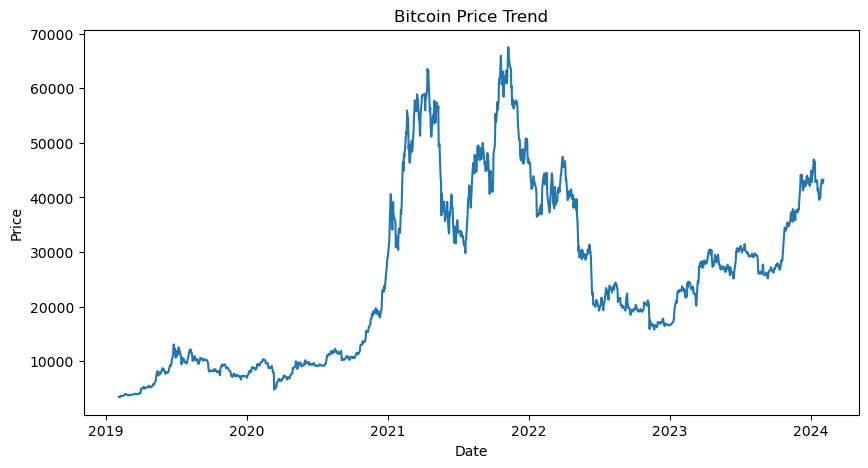

In [34]:

plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Bitcoin_Price"])

plt.title("Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.savefig("C:/data-analysis-portfolio/visualizations/Bitcoin Price Trend.png")
plt.show()

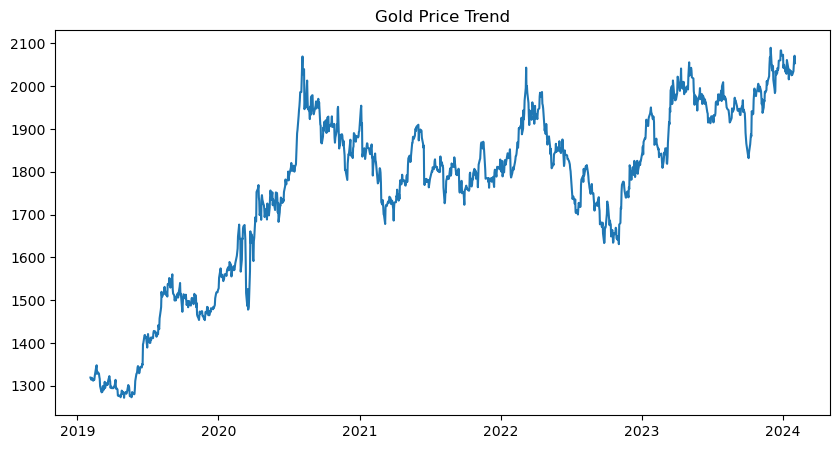

In [12]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Gold_Price"])
plt.title("Gold Price Trend")
plt.show()

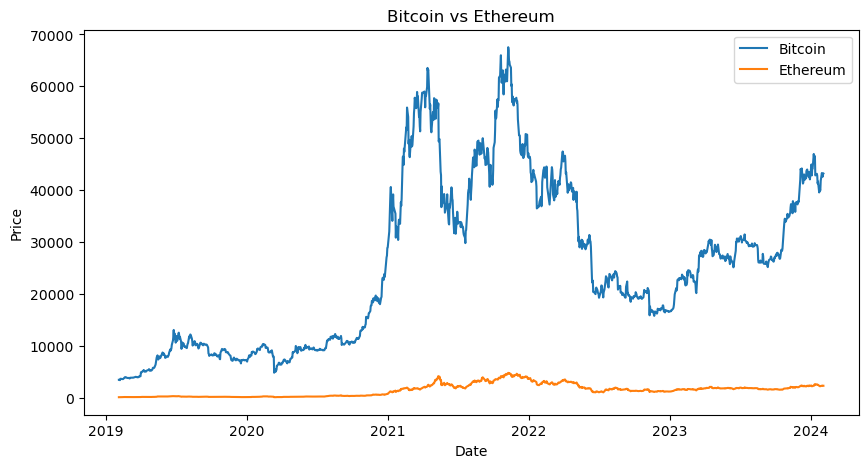

In [35]:
plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Bitcoin_Price"], label="Bitcoin")
plt.plot(df["Date"], df["Ethereum_Price"], label="Ethereum")

plt.title("Bitcoin vs Ethereum")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.savefig("C:/data-analysis-portfolio/visualizations/Bitcoin vs Ethereum.png")


plt.show()

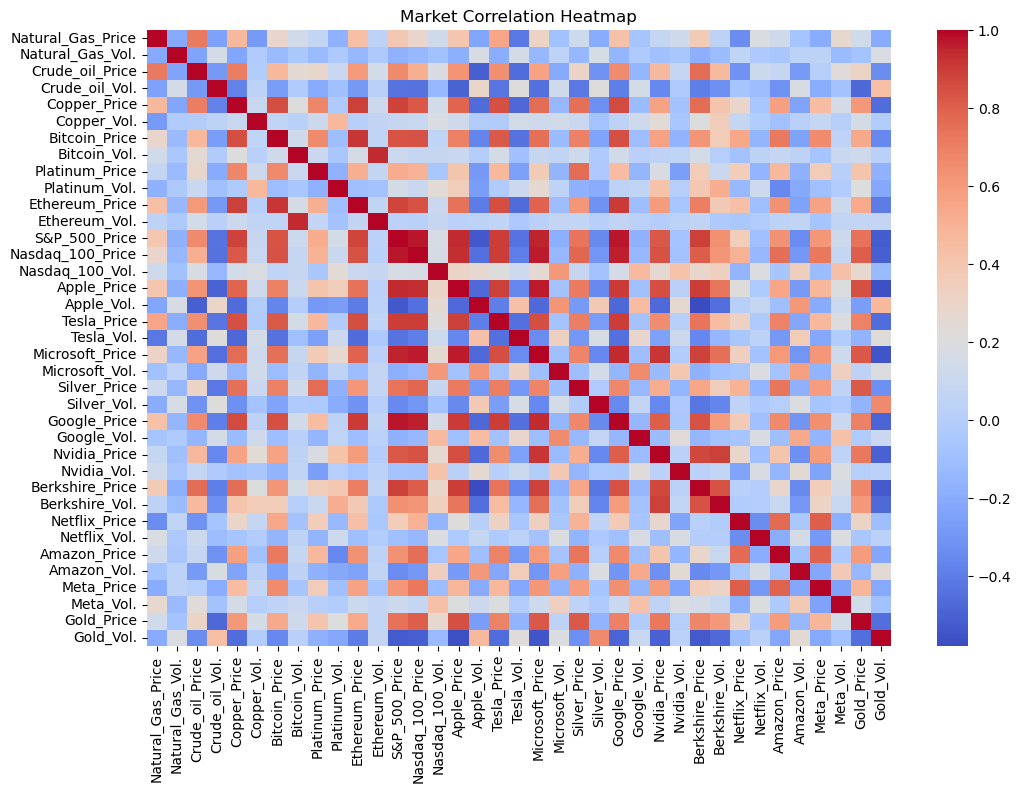

In [36]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

plt.title("Market Correlation Heatmap")
plt.savefig("C:/data-analysis-portfolio/visualizations/Market Correlation Heatmap.png")


plt.show()


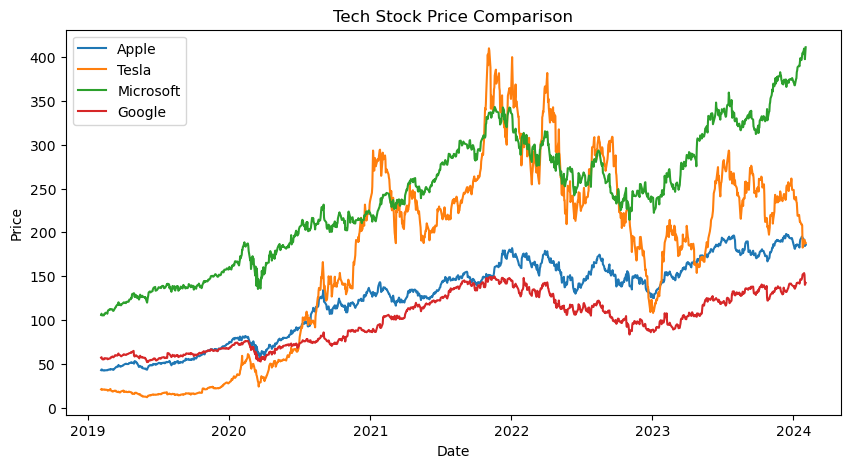

In [37]:
plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Apple_Price"], label="Apple")
plt.plot(df["Date"], df["Tesla_Price"], label="Tesla")
plt.plot(df["Date"], df["Microsoft_Price"], label="Microsoft")
plt.plot(df["Date"], df["Google_Price"], label="Google")

plt.title("Tech Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.savefig("C:/data-analysis-portfolio/visualizations/Tech Stock Price Comparison.png")


plt.show()

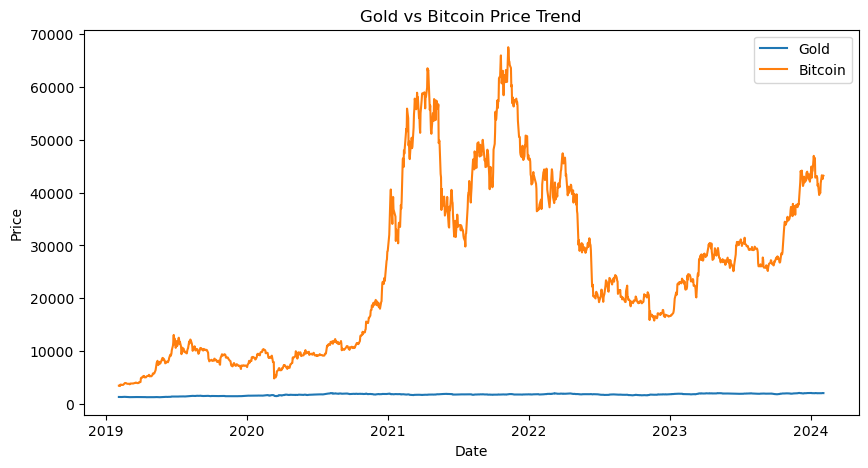

In [38]:
plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Gold_Price"], label="Gold")
plt.plot(df["Date"], df["Bitcoin_Price"], label="Bitcoin")

plt.title("Gold vs Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.savefig("C:/data-analysis-portfolio/visualizations/Gold vs Bitcoin Price Trend.png")


plt.show()